### Data Pre-processing & Transformation

In [1]:
%pip install Sastrawi

import json
import re
from pathlib import Path
from functools import lru_cache

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_extraction import text as sklearn_text

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    STEMMER_ID = StemmerFactory().create_stemmer()
except Exception:
    STEMMER_ID = None

DATA_PATH = Path("/home/fatih/Documents/Projects/nlp-teori/dataset/ICAR_Text_Extracted.json")
OUT_DIR = Path("/home/fatih/Documents/Projects/nlp-teori/output")
OUT_DIR.mkdir(parents=True, exist_ok=True)
TOP_K_FEATURES = 1000

# Untuk mempercepat: set False dulu. Ubah ke True kalau butuh stemming.
USE_STEMMING = False

Note: you may need to restart the kernel to use updated packages.


In [2]:
# 2) Load dataset JSON
with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []
for category, files in data.items():
    if isinstance(files, dict):
        for fname, txt in files.items():
            rows.append({
                "category": category,
                "doc_id": fname,
                "text_raw": str(txt) if txt is not None else ""
            })

df = pd.DataFrame(rows)
print("Jumlah dokumen:", len(df))
df.head()

Jumlah dokumen: 159


,category,doc_id,text_raw
0,Annual Reports,anrep-02003.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...
1,Annual Reports,AR-2019-20.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...
2,Annual Reports,DARE-Annual-Report-2017-18.pdf,\n--- Page 1 ---\nWeb Url -https://icar.gov.in...
3,Annual Reports,DARE-ICAR-Annual-Report 2016-17.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...
4,Annual Reports,DARE-ICAR-AR-2018-19.pdf,\n--- Page 1 ---\nANNUAL REPORT 2018-19 or 04[...


In [3]:
# 3) Data cleaning + normalization + stopword removal
stopwords_en = set(sklearn_text.ENGLISH_STOP_WORDS)
stopwords_id = {
    "dan", "yang", "di", "ke", "dari", "untuk", "pada", "dengan", "atau",
    "ini", "itu", "adalah", "karena", "sebagai", "oleh", "dalam", "juga",
    "agar", "para", "kita", "kami", "mereka", "akan", "telah", "dapat"
}
stopwords_all = stopwords_en.union(stopwords_id)

url_pattern = re.compile(r"http\S+|www\.\S+")
digit_pattern = re.compile(r"\d+")
non_alpha_pattern = re.compile(r"[^a-zA-Z\s]")
space_pattern = re.compile(r"\s+")


def basic_cleaning(text: str) -> str:
    text = text.lower()                                  # lowercase
    text = url_pattern.sub(" ", text)                    # hapus URL
    text = digit_pattern.sub(" ", text)                  # hapus angka
    text = non_alpha_pattern.sub(" ", text)              # hapus tanda baca/simbol
    text = space_pattern.sub(" ", text).strip()          # rapikan spasi
    return text


@lru_cache(maxsize=100_000)
def stem_token(token: str) -> str:
    return STEMMER_ID.stem(token)


def normalize_text(text: str) -> str:
    if not USE_STEMMING or STEMMER_ID is None:
        return text
    tokens = text.split()
    return " ".join(stem_token(t) for t in tokens)


def remove_stopwords(text: str) -> str:
    tokens = [t for t in text.split() if t not in stopwords_all and len(t) > 2]
    return " ".join(tokens)


def preprocess_pipeline(text: str) -> str:
    text = basic_cleaning(text)
    text = normalize_text(text)
    text = remove_stopwords(text)
    return text

In [4]:
# 4) Terapkan preprocessing ke kolom text_clean
df["text_clean"] = df["text_raw"].apply(preprocess_pipeline)

print("Contoh hasil preprocessing:")
df[["category", "doc_id", "text_clean"]].head()

Contoh hasil preprocessing:


,category,doc_id,text_clean
0,Annual Reports,anrep-02003.pdf,page web url dare icar annual report departmen...
1,Annual Reports,AR-2019-20.pdf,page web url page indian council agricultvral ...
2,Annual Reports,DARE-Annual-Report-2017-18.pdf,page web url page indian council agricultural ...
3,Annual Reports,DARE-ICAR-Annual-Report 2016-17.pdf,page web url page indian council agricultural ...
4,Annual Reports,DARE-ICAR-AR-2018-19.pdf,page annual report taaa department agricultura...


## 4.1 Visualisasi Before vs After Preprocessing
Menampilkan perbandingan teks sebelum (`text_raw`) dan sesudah preprocessing (`text_clean`) secara kuantitatif (panjang karakter & token) dan kualitatif (contoh teks).

Contoh before vs after (5 dokumen):


,category,doc_id,text_raw,text_clean
0,Annual Reports,anrep-02003.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...,page web url dare icar annual report departmen...
1,Annual Reports,AR-2019-20.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...,page web url page indian council agricultvral ...
2,Annual Reports,DARE-Annual-Report-2017-18.pdf,\n--- Page 1 ---\nWeb Url -https://icar.gov.in...,page web url page indian council agricultural ...
3,Annual Reports,DARE-ICAR-Annual-Report 2016-17.pdf,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...,page web url page indian council agricultural ...
4,Annual Reports,DARE-ICAR-AR-2018-19.pdf,\n--- Page 1 ---\nANNUAL REPORT 2018-19 or 04[...,page annual report taaa department agricultura...


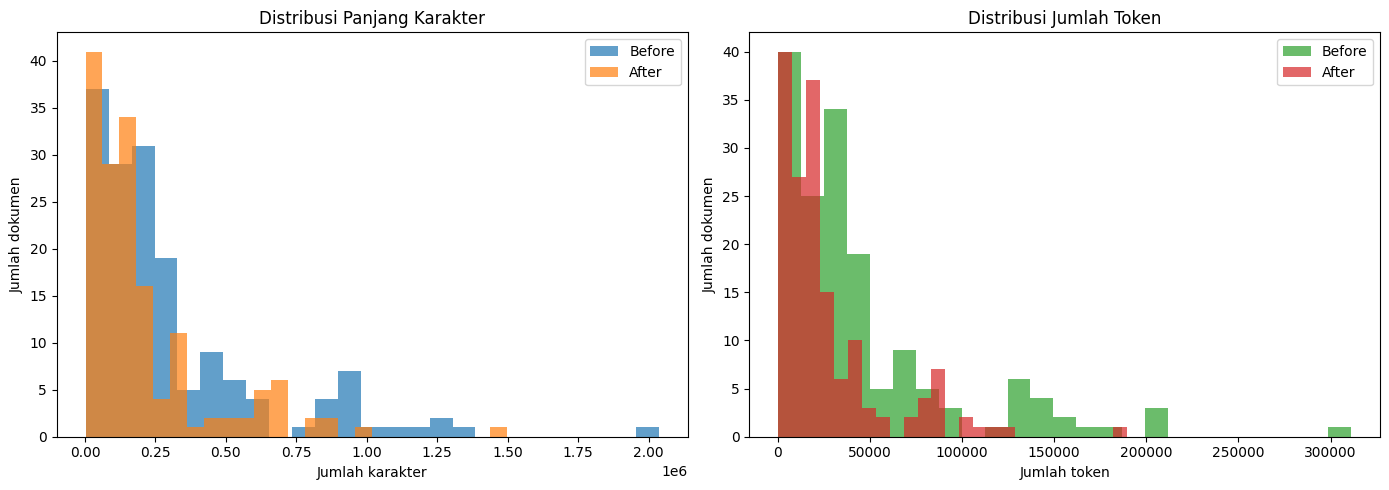

Rata-rata panjang karakter before: 301506.55
Rata-rata panjang karakter after : 213158.64
Pengurangan rata-rata karakter   : 29.30%

Rata-rata token before: 45498.33
Rata-rata token after : 26632.14
Pengurangan rata-rata token   : 41.47%


In [5]:
import matplotlib.pyplot as plt

# Data ringkas before vs after
viz_df = df[["category", "doc_id", "text_raw", "text_clean"]].copy()
viz_df["len_raw"] = viz_df["text_raw"].str.len()
viz_df["len_clean"] = viz_df["text_clean"].str.len()
viz_df["tok_raw"] = viz_df["text_raw"].str.split().str.len()
viz_df["tok_clean"] = viz_df["text_clean"].str.split().str.len()

# 1) Contoh teks sebelum vs sesudah (dipotong agar rapi)
preview = viz_df[["category", "doc_id", "text_raw", "text_clean"]].head(5).copy()
preview["text_raw"] = preview["text_raw"].str.slice(0, 220) + "..."
preview["text_clean"] = preview["text_clean"].str.slice(0, 220) + "..."
print("Contoh before vs after (5 dokumen):")
display(preview)

# 2) Histogram panjang karakter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(viz_df["len_raw"], bins=25, alpha=0.7, color="#1f77b4", label="Before")
axes[0].hist(viz_df["len_clean"], bins=25, alpha=0.7, color="#ff7f0e", label="After")
axes[0].set_title("Distribusi Panjang Karakter")
axes[0].set_xlabel("Jumlah karakter")
axes[0].set_ylabel("Jumlah dokumen")
axes[0].legend()

# 3) Histogram jumlah token
axes[1].hist(viz_df["tok_raw"], bins=25, alpha=0.7, color="#2ca02c", label="Before")
axes[1].hist(viz_df["tok_clean"], bins=25, alpha=0.7, color="#d62728", label="After")
axes[1].set_title("Distribusi Jumlah Token")
axes[1].set_xlabel("Jumlah token")
axes[1].set_ylabel("Jumlah dokumen")
axes[1].legend()

plt.tight_layout()
plt.show()

# 4) Rata-rata pengurangan
char_reduction_pct = (1 - (viz_df["len_clean"].mean() / viz_df["len_raw"].mean())) * 100
tok_reduction_pct = (1 - (viz_df["tok_clean"].mean() / viz_df["tok_raw"].mean())) * 100

print(f"Rata-rata panjang karakter before: {viz_df['len_raw'].mean():.2f}")
print(f"Rata-rata panjang karakter after : {viz_df['len_clean'].mean():.2f}")
print(f"Pengurangan rata-rata karakter   : {char_reduction_pct:.2f}%")
print()
print(f"Rata-rata token before: {viz_df['tok_raw'].mean():.2f}")
print(f"Rata-rata token after : {viz_df['tok_clean'].mean():.2f}")
print(f"Pengurangan rata-rata token   : {tok_reduction_pct:.2f}%")

In [6]:
# 5) Data transformation: TF-IDF
vectorizer = TfidfVectorizer(
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)
X = vectorizer.fit_transform(df["text_clean"])
feature_names = np.array(vectorizer.get_feature_names_out())

print("Shape TF-IDF:", X.shape)
print("Jumlah fitur:", len(feature_names))

Shape TF-IDF: (159, 478980)
Jumlah fitur: 478980


## 5.1 Bag of Words + Visualisasi N-gram
Bagian ini membuat representasi **Bag of Words (BoW)** dan menampilkan n-gram teratas (unigram & bigram) berdasarkan frekuensi kemunculan kata.

Tabel Before vs After - Bag of Words:


,Komponen,Before,After,Selisih (After-Before),Reduksi (%)
0,Jumlah Fitur BoW,5.727170e+05,4.789800e+05,-9.373700e+04,16.367071
1,Jumlah token non-zero (nnz),3.137878e+06,2.055142e+06,-1.082736e+06,34.505357
2,Kerapatan matriks (%),3.445870e+00,2.698530e+00,-7.473392e-01,21.687971


Tabel Before vs After - N-gram:


,Komponen,Before,After,Selisih (After-Before),Reduksi (%)
0,Unigram,58848,47353,-11495,19.533374
1,Bigram,513869,431627,-82242,16.004468


Tabel Per-feature (Top 20) - Unigram:


,feature,n,count_before,count_after,selisih,perubahan_%
554464,prac,1,0,244,244,100.000000
485406,nicgw,1,45,181,136,302.222222
165180,cas,1,111,242,131,118.018018
469620,mon,1,107,195,88,82.242991
582292,qdty,1,0,80,80,100.000000
386270,ingr,1,163,229,66,40.490798
181348,cnrb,1,0,66,66,100.000000
315462,fsw,1,0,62,62,100.000000
474144,mtu,1,188,244,56,29.787234
646593,singh,1,4023,4076,53,1.317425


Tabel Per-feature (Top 20) - Bigram:


,feature,n,count_before,count_after,selisih,perubahan_%
453424,maturity days,2,28,2851,2823,10082.142857
524057,page icar,2,54,2364,2310,4277.777778
716160,title itk,2,0,2065,2065,100.000000
76197,advisory farmers,2,0,1667,1667,100.000000
784657,yield maturity,2,10,1575,1565,15650.000000
329179,government india,2,0,1118,1118,100.000000
602200,report page,2,0,1092,1092,100.000000
678841,suitable irrigated,2,6,1079,1073,17883.333333
652360,soil deficient,2,0,1043,1043,100.000000
744266,used itk,2,0,966,966,100.000000


File per-feature tersimpan: /home/fatih/Documents/Projects/nlp-teori/output/icar_bow_ngram_per_feature_compare.csv


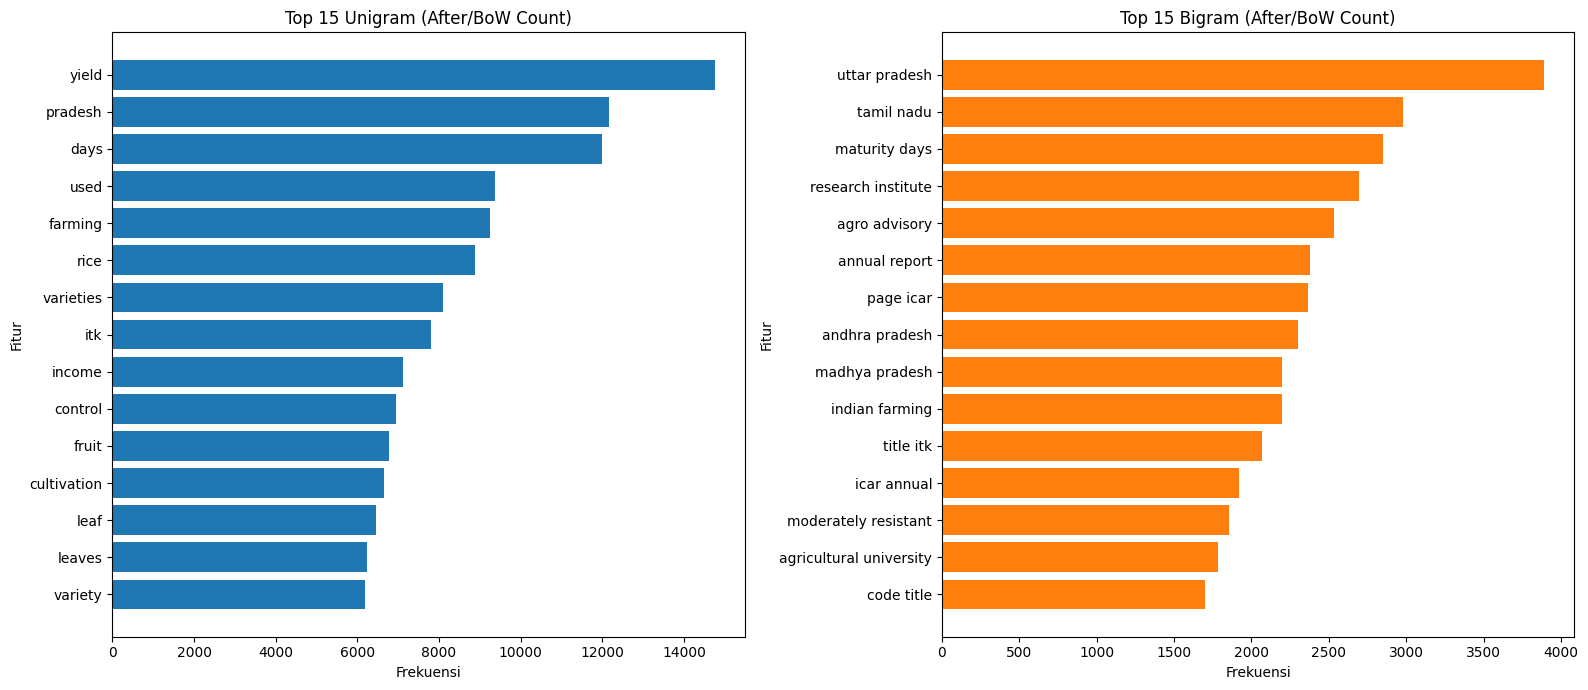

In [12]:
# 5.1) Bag of Words (BoW) + N-gram: Before vs After (tabel terpisah + per-feature)
# Before = text_raw, After = text_clean

# === BoW BEFORE (teks mentah) ===
bow_vectorizer_before = CountVectorizer(
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)
X_bow_before = bow_vectorizer_before.fit_transform(df["text_raw"].fillna(""))
bow_features_before = np.array(bow_vectorizer_before.get_feature_names_out())

term_counts_before = np.asarray(X_bow_before.sum(axis=0)).ravel()
ngram_before_df = pd.DataFrame({
    "feature": bow_features_before,
    "count_before": term_counts_before
})
ngram_before_df["n"] = ngram_before_df["feature"].str.split().str.len()

# === BoW AFTER (teks hasil preprocessing) ===
bow_vectorizer_after = CountVectorizer(
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)
X_bow = bow_vectorizer_after.fit_transform(df["text_clean"].fillna(""))
bow_feature_names = np.array(bow_vectorizer_after.get_feature_names_out())

term_counts = np.asarray(X_bow.sum(axis=0)).ravel()
ngram_df = pd.DataFrame({
    "feature": bow_feature_names,
    "count_after": term_counts
})
ngram_df["n"] = ngram_df["feature"].str.split().str.len()

# === TABEL 1: Ringkasan Bag of Words ===
bow_compare_df = pd.DataFrame([
    {"Komponen": "Jumlah Fitur BoW", "Before": len(bow_features_before), "After": len(bow_feature_names)},
    {"Komponen": "Jumlah token non-zero (nnz)", "Before": int(X_bow_before.nnz), "After": int(X_bow.nnz)},
    {
        "Komponen": "Kerapatan matriks (%)",
        "Before": (X_bow_before.nnz / (X_bow_before.shape[0] * X_bow_before.shape[1])) * 100,
        "After": (X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])) * 100
    }
])
bow_compare_df["Selisih (After-Before)"] = bow_compare_df["After"] - bow_compare_df["Before"]
bow_compare_df["Reduksi (%)"] = np.where(
    bow_compare_df["Before"] > 0,
    (1 - (bow_compare_df["After"] / bow_compare_df["Before"])) * 100,
    0.0
)

print("Tabel Before vs After - Bag of Words:")
display(bow_compare_df)

# === TABEL 2: Ringkasan N-gram ===
ngram_compare_df = pd.DataFrame([
    {"Komponen": "Unigram", "Before": int((ngram_before_df["n"] == 1).sum()), "After": int((ngram_df["n"] == 1).sum())},
    {"Komponen": "Bigram", "Before": int((ngram_before_df["n"] == 2).sum()), "After": int((ngram_df["n"] == 2).sum())}
])
ngram_compare_df["Selisih (After-Before)"] = ngram_compare_df["After"] - ngram_compare_df["Before"]
ngram_compare_df["Reduksi (%)"] = np.where(
    ngram_compare_df["Before"] > 0,
    (1 - (ngram_compare_df["After"] / ngram_compare_df["Before"])) * 100,
    0.0
)

print("Tabel Before vs After - N-gram:")
display(ngram_compare_df)

# === TABEL 3: Per-feature Before vs After ===
feature_compare_df = pd.merge(
    ngram_before_df[["feature", "n", "count_before"]],
    ngram_df[["feature", "n", "count_after"]],
    on="feature",
    how="outer",
    suffixes=("_before", "_after")
)

feature_compare_df["n"] = feature_compare_df["n_before"].fillna(feature_compare_df["n_after"]).astype(int)
feature_compare_df["count_before"] = feature_compare_df["count_before"].fillna(0).astype(int)
feature_compare_df["count_after"] = feature_compare_df["count_after"].fillna(0).astype(int)
feature_compare_df = feature_compare_df[["feature", "n", "count_before", "count_after"]]
feature_compare_df["selisih"] = feature_compare_df["count_after"] - feature_compare_df["count_before"]
feature_compare_df["perubahan_%"] = np.where(
    feature_compare_df["count_before"] > 0,
    ((feature_compare_df["count_after"] - feature_compare_df["count_before"]) / feature_compare_df["count_before"]) * 100,
    np.where(feature_compare_df["count_after"] > 0, 100.0, 0.0)
)

TOP_FEATURE_COMPARE = 20
per_feature_unigram = (
    feature_compare_df[feature_compare_df["n"] == 1]
    .sort_values("selisih", ascending=False)
    .head(TOP_FEATURE_COMPARE)
)
per_feature_bigram = (
    feature_compare_df[feature_compare_df["n"] == 2]
    .sort_values("selisih", ascending=False)
    .head(TOP_FEATURE_COMPARE)
)

print(f"Tabel Per-feature (Top {TOP_FEATURE_COMPARE}) - Unigram:")
display(per_feature_unigram)

print(f"Tabel Per-feature (Top {TOP_FEATURE_COMPARE}) - Bigram:")
display(per_feature_bigram)

# Simpan tabel lengkap per-feature agar bisa dicek semua fitur
per_feature_path = OUT_DIR / "icar_bow_ngram_per_feature_compare.csv"
feature_compare_df.sort_values(["n", "selisih"], ascending=[True, False]).to_csv(per_feature_path, index=False)
print("File per-feature tersimpan:", per_feature_path)

# === Top n-gram AFTER (opsional visualisasi) ===
TOP_SHOW = 15
unigram_top = feature_compare_df[feature_compare_df["n"] == 1].sort_values("count_after", ascending=False).head(TOP_SHOW)
bigram_top = feature_compare_df[feature_compare_df["n"] == 2].sort_values("count_after", ascending=False).head(TOP_SHOW)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(unigram_top["feature"][::-1], unigram_top["count_after"][::-1], color="#1f77b4")
axes[0].set_title(f"Top {len(unigram_top)} Unigram (After/BoW Count)")
axes[0].set_xlabel("Frekuensi")
axes[0].set_ylabel("Fitur")

axes[1].barh(bigram_top["feature"][::-1], bigram_top["count_after"][::-1], color="#ff7f0e")
axes[1].set_title(f"Top {len(bigram_top)} Bigram (After/BoW Count)")
axes[1].set_xlabel("Frekuensi")
axes[1].set_ylabel("Fitur")

plt.tight_layout()
plt.show()

In [8]:
# 6) Feature selection: pilih kata relevan (top-k mean TF-IDF)
mean_scores = np.asarray(X.mean(axis=0)).ravel()

# BEFORE: semua fitur hasil TF-IDF (belum diseleksi)
before_features_df = pd.DataFrame({
    "feature": feature_names,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=False)

# AFTER: fitur terpilih top-k
top_k = min(TOP_K_FEATURES, len(feature_names))
top_idx = np.argsort(mean_scores)[::-1][:top_k]

X_selected = X[:, top_idx]
selected_features = feature_names[top_idx]
selected_df = pd.DataFrame({
    "feature": selected_features,
    "mean_tfidf": mean_scores[top_idx]
}).sort_values("mean_tfidf", ascending=False)

# Ringkasan before vs after
compare_summary = pd.DataFrame([
    {"Tahap": "Before (semua fitur)", "Jumlah Fitur": len(feature_names)},
    {"Tahap": "After (top-k terpilih)", "Jumlah Fitur": len(selected_features)}
])

print("Ringkasan jumlah fitur before vs after:")
display(compare_summary)

print("Top 20 BEFORE (sebelum feature selection):")
display(before_features_df.head(20))

print("Top 20 AFTER (sesudah feature selection):")
display(selected_df.head(20))

Ringkasan jumlah fitur before vs after:


,Tahap,Jumlah Fitur
0,Before (semua fitur),478980
1,After (top-k terpilih),1000


Top 20 BEFORE (sebelum feature selection):


,feature,mean_tfidf
475324,yield,0.045361
147843,farming,0.036702
322843,pradesh,0.030826
98760,days,0.030401
163506,fruit,0.030219
367806,rice,0.029290
455768,varieties,0.028661
93461,cultivation,0.025492
456661,variety,0.023897
450923,used,0.023844


Top 20 AFTER (sesudah feature selection):


,feature,mean_tfidf
0,yield,0.045361
1,farming,0.036702
2,pradesh,0.030826
3,days,0.030401
4,fruit,0.030219
5,rice,0.029290
6,varieties,0.028661
7,cultivation,0.025492
8,variety,0.023897
9,used,0.023844


In [9]:
# 6) Feature selection: pilih kata relevan (top-k mean TF-IDF)
mean_scores = np.asarray(X.mean(axis=0)).ravel()

# BEFORE: semua fitur hasil TF-IDF (belum diseleksi)
before_features_df = pd.DataFrame({
    "feature": feature_names,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=False)

# AFTER: fitur terpilih top-k
top_k = min(TOP_K_FEATURES, len(feature_names))
top_idx = np.argsort(mean_scores)[::-1][:top_k]

X_selected = X[:, top_idx]
selected_features = feature_names[top_idx]
selected_df = pd.DataFrame({
    "feature": selected_features,
    "mean_tfidf": mean_scores[top_idx]
}).sort_values("mean_tfidf", ascending=False)

# Ringkasan before vs after
removed_count = len(feature_names) - len(selected_features)
reduction_pct = (removed_count / len(feature_names)) * 100 if len(feature_names) > 0 else 0

compare_summary = pd.DataFrame([
    {"Tahap": "Before (semua fitur)", "Jumlah Fitur": len(feature_names)},
    {"Tahap": "After (top-k terpilih)", "Jumlah Fitur": len(selected_features)},
    {"Tahap": "Fitur terbuang", "Jumlah Fitur": removed_count}
])

print("Ringkasan jumlah fitur before vs after:")
display(compare_summary)
print(f"Persentase reduksi fitur: {reduction_pct:.2f}%")

print("\nCatatan: Top-20 BEFORE dan AFTER bisa sama karena feature selection mengambil fitur dengan mean_tfidf tertinggi.")
print("Yang berubah adalah jumlah total fitur (dimensi), bukan ranking 20 teratas.")

print("\nTop 20 BEFORE (sebelum feature selection):")
display(before_features_df.head(20))

print("Top 20 AFTER (sesudah feature selection):")
display(selected_df.head(20))

# Tampilkan contoh fitur yang DIBUANG agar perbedaan lebih terlihat
if removed_count > 0:
    removed_features_df = before_features_df.iloc[top_k:].copy()
    print("Contoh 20 fitur yang dibuang (bukan top-k):")
    display(removed_features_df.head(20))
else:
    print("Tidak ada fitur yang dibuang (top_k >= jumlah fitur awal).")

Ringkasan jumlah fitur before vs after:


,Tahap,Jumlah Fitur
0,Before (semua fitur),478980
1,After (top-k terpilih),1000
2,Fitur terbuang,477980


Persentase reduksi fitur: 99.79%

Catatan: Top-20 BEFORE dan AFTER bisa sama karena feature selection mengambil fitur dengan mean_tfidf tertinggi.
Yang berubah adalah jumlah total fitur (dimensi), bukan ranking 20 teratas.

Top 20 BEFORE (sebelum feature selection):


,feature,mean_tfidf
475324,yield,0.045361
147843,farming,0.036702
322843,pradesh,0.030826
98760,days,0.030401
163506,fruit,0.030219
367806,rice,0.029290
455768,varieties,0.028661
93461,cultivation,0.025492
456661,variety,0.023897
450923,used,0.023844


Top 20 AFTER (sesudah feature selection):


,feature,mean_tfidf
0,yield,0.045361
1,farming,0.036702
2,pradesh,0.030826
3,days,0.030401
4,fruit,0.030219
5,rice,0.029290
6,varieties,0.028661
7,cultivation,0.025492
8,variety,0.023897
9,used,0.023844


Contoh 20 fitur yang dibuang (bukan top-k):


,feature,mean_tfidf
265575,mid,0.003772
318696,possible,0.003771
427250,technological,0.003767
294750,organic farming,0.003764
472753,write,0.003764
470290,winter,0.003763
324023,prcia,0.003762
214306,insects,0.003762
412312,strategic,0.003757
88733,critical,0.003755


## 6.1 Visualisasi Before vs After: Transformation & Feature Selection
Visualisasi ini membandingkan kondisi **sebelum** (TF-IDF penuh) dan **sesudah** (TF-IDF tereduksi/top-k) pada proses transformasi dan seleksi fitur.

Ringkasan Before vs After:


,Tahap,Jumlah Dokumen,Jumlah Fitur,Rata-rata fitur non-zero/dokumen,Kerapatan Matriks (%)
0,Before (TF-IDF penuh),159,478980,12925.421384,2.698530
1,After (TF-IDF tereduksi),159,1000,575.886792,57.588679


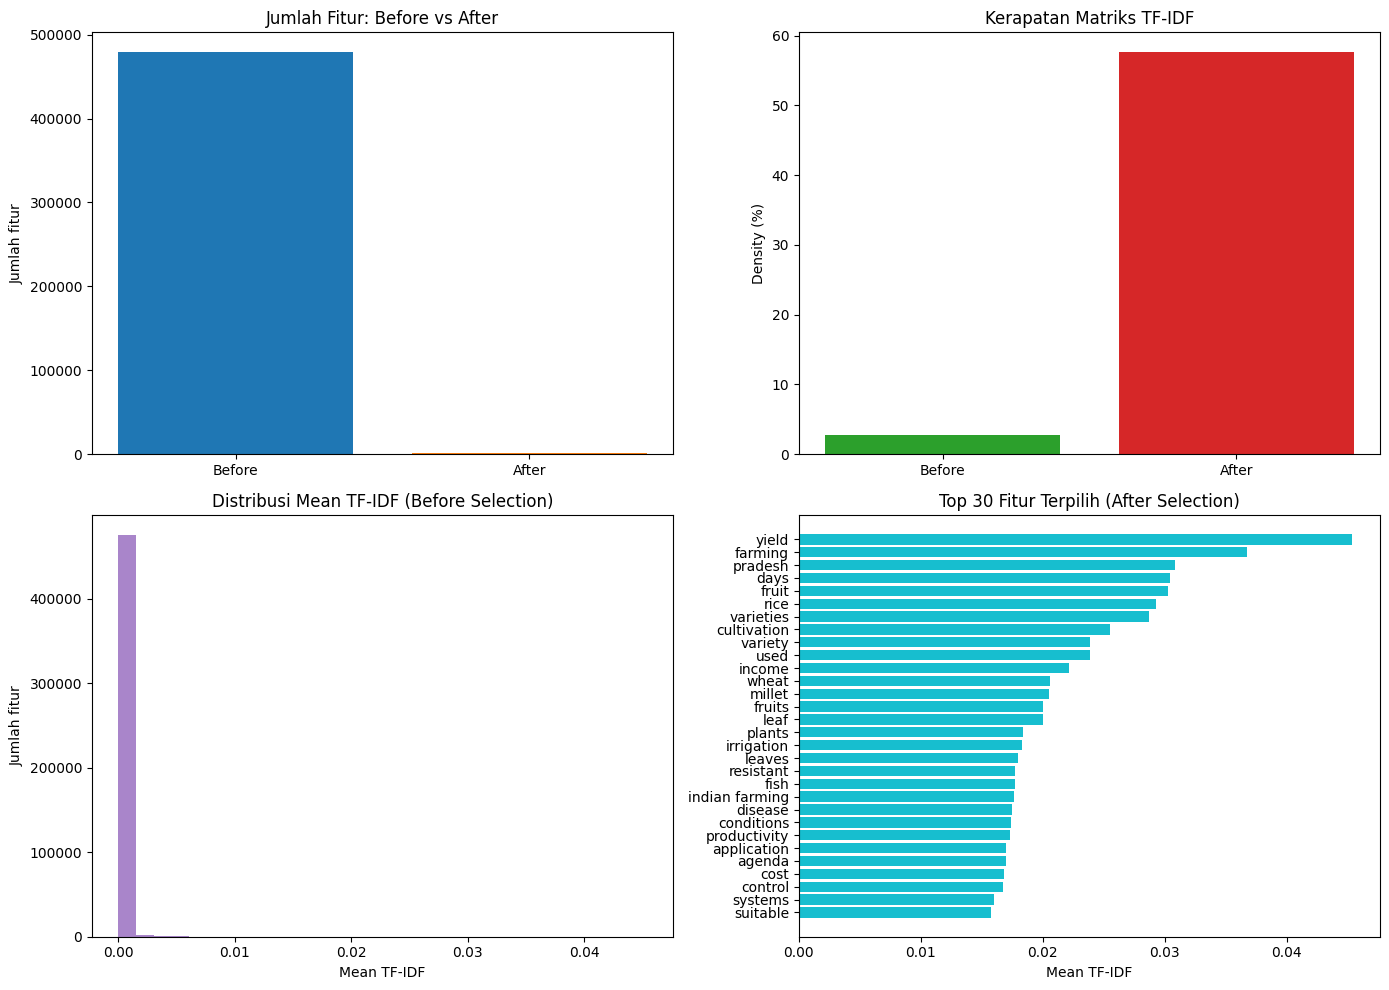

Reduksi jumlah fitur: 99.79%


In [10]:
# Ringkasan metrik before vs after
before_features = X.shape[1]
after_features = X_selected.shape[1]

before_density = X.nnz / (X.shape[0] * X.shape[1])
after_density = X_selected.nnz / (X_selected.shape[0] * X_selected.shape[1])

before_nnz_doc = np.asarray((X != 0).sum(axis=1)).ravel()
after_nnz_doc = np.asarray((X_selected != 0).sum(axis=1)).ravel()

summary_df = pd.DataFrame([
    {
        "Tahap": "Before (TF-IDF penuh)",
        "Jumlah Dokumen": X.shape[0],
        "Jumlah Fitur": before_features,
        "Rata-rata fitur non-zero/dokumen": before_nnz_doc.mean(),
        "Kerapatan Matriks (%)": before_density * 100
    },
    {
        "Tahap": "After (TF-IDF tereduksi)",
        "Jumlah Dokumen": X_selected.shape[0],
        "Jumlah Fitur": after_features,
        "Rata-rata fitur non-zero/dokumen": after_nnz_doc.mean(),
        "Kerapatan Matriks (%)": after_density * 100
    }
])

print("Ringkasan Before vs After:")
display(summary_df)

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Jumlah fitur before vs after
axes[0, 0].bar(["Before", "After"], [before_features, after_features], color=["#1f77b4", "#ff7f0e"])
axes[0, 0].set_title("Jumlah Fitur: Before vs After")
axes[0, 0].set_ylabel("Jumlah fitur")

# 2) Kerapatan matriks before vs after
axes[0, 1].bar(["Before", "After"], [before_density * 100, after_density * 100], color=["#2ca02c", "#d62728"])
axes[0, 1].set_title("Kerapatan Matriks TF-IDF")
axes[0, 1].set_ylabel("Density (%)")

# 3) Distribusi skor mean TF-IDF (semua fitur = before selection)
axes[1, 0].hist(mean_scores, bins=30, color="#9467bd", alpha=0.8)
axes[1, 0].set_title("Distribusi Mean TF-IDF (Before Selection)")
axes[1, 0].set_xlabel("Mean TF-IDF")
axes[1, 0].set_ylabel("Jumlah fitur")

# 4) Top-k mean TF-IDF (after selection)
top_plot_k = min(30, len(selected_features))
top_names = selected_features[:top_plot_k]
top_vals = mean_scores[top_idx][:top_plot_k]

axes[1, 1].barh(top_names[::-1], top_vals[::-1], color="#17becf")
axes[1, 1].set_title(f"Top {top_plot_k} Fitur Terpilih (After Selection)")
axes[1, 1].set_xlabel("Mean TF-IDF")

plt.tight_layout()
plt.show()

# Persentase reduksi dimensi
reduction_pct = (1 - (after_features / before_features)) * 100
print(f"Reduksi jumlah fitur: {reduction_pct:.2f}%")

In [11]:
# 7) Simpan hasil
preprocessed_path = OUT_DIR / "icar_preprocessed.csv"
features_path = OUT_DIR / "icar_selected_features.csv"
tfidf_selected_path = OUT_DIR / "icar_tfidf_selected.csv"

# a) Teks hasil preprocessing
df[["category", "doc_id", "text_clean"]].to_csv(preprocessed_path, index=False)

# b) Fitur terpilih
selected_df.to_csv(features_path, index=False)

# c) Matriks TF-IDF tereduksi
tfidf_df = pd.DataFrame(X_selected.toarray(), columns=selected_features)
tfidf_df.insert(0, "doc_id", df["doc_id"].values)
tfidf_df.to_csv(tfidf_selected_path, index=False)

print("Selesai disimpan:")
print("-", preprocessed_path)
print("-", features_path)
print("-", tfidf_selected_path)

Selesai disimpan:
- /home/fatih/Documents/Projects/nlp-teori/output/icar_preprocessed.csv
- /home/fatih/Documents/Projects/nlp-teori/output/icar_selected_features.csv
- /home/fatih/Documents/Projects/nlp-teori/output/icar_tfidf_selected.csv


In [11]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
from IPython.display import display

# Ekstraksi Frekuensi N-gram (Tabel Feature dan Frekuensi)
df_prep = pd.read_csv("output/icar_preprocessed.csv")
texts = df_prep["text_clean"].fillna("")

def get_ngram_freq(texts, ngram_range, top_n=15):
    vec = CountVectorizer(ngram_range=ngram_range)
    X_counts = vec.fit_transform(texts)
    
    # Hitung jumlah frekuensi masing-masing fitur
    sum_words = X_counts.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    
    # Sortir berdasarkan frekuensi tertinggi
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    df_freq = pd.DataFrame(words_freq[:top_n], columns=["feature", "frekuensi"])
    return df_freq

print("N-gram: ngram_range=(1,1)")
df_1_1 = get_ngram_freq(texts, ngram_range=(1,1), top_n=15)
display(df_1_1)

print("\nN-gram: ngram_range=(2,2)")
df_2_2 = get_ngram_freq(texts, ngram_range=(2,2), top_n=15)
display(df_2_2)

print("\nN-gram: ngram_range=(1,2)")
df_1_2 = get_ngram_freq(texts, ngram_range=(1,2), top_n=15)
display(df_1_2)

N-gram: ngram_range=(1,1)


,feature,frekuensi
0,icar,27528
1,page,19754
2,farmers,19594
3,agricultural,19566
4,research,18816
5,water,17500
6,crop,15848
7,yield,14749
8,production,14734
9,management,14436



N-gram: ngram_range=(2,2)


,feature,frekuensi
0,new delhi,5389
1,agricultural research,5143
2,uttar pradesh,3890
3,tamil nadu,2980
4,maturity days,2851
5,research institute,2697
6,agro advisory,2534
7,indian council,2513
8,council agricultural,2469
9,annual report,2378



N-gram: ngram_range=(1,2)


,feature,frekuensi
0,icar,27528
1,page,19754
2,farmers,19594
3,agricultural,19566
4,research,18816
5,water,17500
6,crop,15848
7,yield,14749
8,production,14734
9,management,14436


In [3]:
print("Bag of Words (BoW):")
# BoW dasarnya adalah unigram CountVectorizer
df_bow = get_ngram_freq(texts, ngram_range=(1,1), top_n=15)
display(df_bow)

Bag of Words (BoW):


Bag of Words (BoW):


,feature,frekuensi
0,icar,27528
1,page,19754
2,farmers,19594
3,agricultural,19566
4,research,18816
5,water,17500
6,crop,15848
7,yield,14749
8,production,14734
9,management,14436


In [ ]:
import pandas as pd
from IPython.display import display
import re
from sklearn.feature_extraction import text as sklearn_text

# Definisi ulang pola jika belum ada
url_pattern = re.compile(r"http\S+|www\.\S+")
digit_pattern = re.compile(r"\d+")
non_alpha_pattern = re.compile(r"[^a-zA-Z\s]")
space_pattern = re.compile(r"\s+")

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    STEMMER_ID = StemmerFactory().create_stemmer()
except Exception:
    STEMMER_ID = None

stopwords_en = set(sklearn_text.ENGLISH_STOP_WORDS)
stopwords_id = {
    "dan", "yang", "di", "ke", "dari", "untuk", "pada", "dengan", "atau",
    "ini", "itu", "adalah", "karena", "sebagai", "oleh", "dalam", "juga",
    "agar", "para", "kita", "kami", "mereka", "akan", "telah", "dapat"
}
stopwords_all = stopwords_en.union(stopwords_id)

# Ambil contoh teks pertama dari dataset awal untuk demonstrasi (karena df sudah ditimpa teks preprocessed)
import json
with open("dataset/ICAR_Text_Extracted.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)
    # Ambil nilai teks pertama yang ada
    for k, v in raw_data.items():
        if isinstance(v, dict):
            for fname, txt in v.items():
                if txt:
                    sample_text = str(txt)
                    break
        break

# 1. Case Folding
text_cf = sample_text.lower()
df_cf = pd.DataFrame([{"Before case Folding": sample_text, "After case Folding": text_cf}])

# 2. Remove URL
text_ru = url_pattern.sub(" ", text_cf)
df_ru = pd.DataFrame([{"Before remove URL": text_cf, "After remove URL": text_ru}])

# 3. Remove Non-Alphabet (Menghapus angka dan karakter selain alphabet)
text_rna = digit_pattern.sub(" ", text_ru)
text_rna = non_alpha_pattern.sub(" ", text_rna)
text_rna = non_alpha_pattern.sub(" ", text_rna)
df_rna = pd.DataFrame([{"Before remove non-alphabet": text_ru, "After remove non-alphabet": text_rna}])

# 4. Normalize Whitespace
df_rna = pd.DataFrame([{"Before remove non-alphabet": text_ru, "After remove non-alphabet": text_rna}])

# 4. Normalize Whitespace
text_nw = space_pattern.sub(" ", text_rna).strip()
df_nw = pd.DataFrame([{"Before normalize whitespace": text_rna, "After normalize whitespace": text_nw}])

# 5. Stopword Removal
tokens_sr = [t for t in text_nw.split() if t not in stopwords_all and len(t) > 2]
text_sr = " ".join(tokens_sr)
df_sr = pd.DataFrame([{"Before stopword removal": text_nw, "After stopword removal": text_sr}])

# 6. Stemming
if STEMMER_ID is not None:
    text_st = " ".join(STEMMER_ID.stem(t) for t in text_sr.split())
else:
    text_st = text_sr
df_st = pd.DataFrame([{"Before stemming": text_sr, "After stemming": text_st}])

print("1. Case Folding:")
display(df_cf)

print("\n2. Remove URL:")
display(df_ru)

print("\n3. Remove Non-Alphabet:")
display(df_rna)

print("\n4. Normalize Whitespace:")
display(df_nw)

print("\n5. Stopword Removal:")
display(df_sr)

print("\n6. Stemming:")
display(df_st)

1. Case Folding:


,Before case Folding,After case Folding
0,\n--- Page 1 ---\nWeb Url-https://icar.gov.in/...,\n--- page 1 ---\nweb url-https://icar.gov.in/...



2. Remove URL:


,Before remove URL,After remove URL
0,\n--- page 1 ---\nweb url-https://icar.gov.in/...,\n--- page 1 ---\nweb url- \ndare/icar\nannual...



3. Remove Non-Alphabet:


...

,Before normalize whitespace,After normalize whitespace
0,\n page \nweb url \ndare icar\nannual...,page web url dare icar annual report departmen...



5. Stopword Removal:


,Before stopword removal,After stopword removal
0,page web url dare icar annual report departmen...,page web url dare icar annual report departmen...



6. Stemming:


,Before stemming,After stemming
0,page web url dare icar annual report departmen...,page web url dare icar annual report departmen...
